# Determine Minimum $n_k$ for Predicting L1/L2/L3 Products (with Storage and Fallbacks)

**Initialize:**
- Error tolerance $\epsilon$
- Maximum iterations $\texttt{max\_iterations}$
- Geographic regions $k$
- Science Data System $\texttt{SDS}$
- Onboard storage limit $\texttt{storage\_limit}$

---

**For each region $k$:**
1. Set $n_k \leftarrow$ initial small sample size  
2. Set $\texttt{iteration} \leftarrow 0$  
3. Set $\texttt{sufficient} \leftarrow \text{False}$

---

**While** $\texttt{not sufficient}$ and $\texttt{iteration} < \texttt{max\_iterations}$:
- Collect $n_k$ Level 0 measurements  
  $\rightarrow \ \texttt{L0\_data} \leftarrow \texttt{collect\_L0\_data}(k, n_k)$
- Process Level 0 data to Level 1B, 2B  
  $\rightarrow \ (\texttt{L1B\_data}, \texttt{L2B\_data}) \leftarrow \texttt{SDS.process}(L0\_data)$
- Apply PCA  
  $\rightarrow \ \tilde{W} \leftarrow PCA(\texttt{L1B\_data})$  
  $\rightarrow \ \tilde{Q} \leftarrow PCA(\texttt{L2B\_data})$
- Form combined matrix  
  $\rightarrow \ \tilde{X} \leftarrow [\tilde{W} \mid \tilde{Q}]$
- **Check onboard storage constraint**  
  $\rightarrow \ \texttt{X\_size} \leftarrow \texttt{calculate\_size}(\tilde{X})$

---

**If** $\texttt{X\_size} > \texttt{storage\_limit}$:
- Reduce $n_k$ to fit within storage limit  
- Generate synthetic data with PLoM  
  $\rightarrow \ \tilde{X}^* \leftarrow \texttt{PLoM.generate}([\texttt{train\_W} \mid \texttt{train\_Q}])$
- Predict using conditional expectation  
  $\rightarrow \ \texttt{predicted\_Q} \leftarrow \texttt{predict\_conditional\_expectation}(\texttt{test\_W}, \tilde{X}^*)$
- Compute error metrics  
  $\rightarrow \ \texttt{RMSE}, \texttt{RAE}$

- **If** error too large:
  - Apply alternative methods (fallbacks):
    - **LUSI**: Learn statistical invariants  
      $\rightarrow \ \texttt{invariants} \leftarrow \texttt{learn\_statistical\_invariants}()$
    - **Model-X knockoffs**: Apply conditional variable selection
    - **Attention-based models**: Focus on key regions or features
  - Combine with PLoM or bypass it

---

**Else (if within storage):**
- Split into training and test sets  
  $\rightarrow \ (\texttt{train\_W}, \texttt{test\_W}, \texttt{train\_Q}, \texttt{test\_Q})$
- Generate synthetic data with PLoM  
  $\rightarrow \ \tilde{X}^*$
- Predict and compute error as usual

---

**Final check for all paths:**
- **If** $\texttt{RMSE} \leq \epsilon$ and $\texttt{RAE} \leq \epsilon$
  - Set $\texttt{sufficient} \leftarrow \text{True}$
  - Print → Region $k$: sufficient with $n_k = n_k$
- **Else**
  - **While** $\tilde{X}^*$ fits within onboard storage:
    - Increase $n_k$: $n_k \leftarrow n_k + \texttt{increment\_value}$
    - Update $\tilde{X}$ and check $\texttt{X\_size}$
    - If $\texttt{X\_size} > \texttt{storage\_limit}$, break loop
    - Regenerate $\tilde{X}^*$ with updated $n_k$
    - Recompute predictions and error metrics
    - **If** $\texttt{RMSE} \leq \epsilon$ and $\texttt{RAE} \leq \epsilon$:
      - Set $\texttt{sufficient} \leftarrow \text{True}$
      - Print → Region $k$: sufficient with $n_k = n_k$
      - Break loop

---

**If** $\texttt{iteration} == \texttt{max\_iterations}$
- Print → Region $k$: did not converge within max iterations

---

**After all regions complete**
- Deploy direct prediction pipeline (bypass SDS)


In [4]:
import netCDF4 as nc
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import seaborn as sns
import shutil
import pickle
import re
import random
import sys

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>See what is in EMIT .nc files

In [5]:
def ncdump(nc_file, verb=True):
    """
    Prints the content (similar to ncdump -h) of a netCDF file including groups.

    """
    def print_group_info(group, prefix=""):
        # Print group's dimensions
        print(f"{prefix}Dimensions:")
        for dimname, dimobj in group.dimensions.items():
            print(f"{prefix}\t{dimname}: size {len(dimobj)}")

        # Print group's variables
        print(f"{prefix}Variables:")
        for varname, varobj in group.variables.items():
            print(f"{prefix}\t{varname}: shape {varobj.shape}, type {varobj.dtype}")
            # Print attributes of each variable
            for attrname in varobj.ncattrs():
                print(f"{prefix}\t\t{attrname}: {getattr(varobj, attrname)}")

        # Print group's attributes
        print(f"{prefix}Attributes:")
        for attrname in group.ncattrs():
            print(f"{prefix}\t{attrname}: {getattr(group, attrname)}")

        # Recursively print information for subgroups
        for subgroup_name, subgroup in group.groups.items():
            print(f"{prefix}Group: {subgroup_name}")
            print_group_info(subgroup, prefix + "\t")

    with nc.Dataset(nc_file, 'r') as ds:
        # Print type of netCDF file
        print(f"File format: {ds.file_format}")

        # Start with the root group
        print_group_info(ds)

In [8]:
#path to L1B RAD test file
nc_file_path = '/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L1B/L1B_RAD/EMIT_L1B_RAD_001_20230227T111506_2305807_012.nc'

# Call
ncdump(nc_file_path)

dd=nc.Dataset(nc_file_path)
#dd.get_variables_by_attributes
# to list the groups
print(dd.groups.keys())

wavelengths = dd.groups['sensor_band_parameters'].variables['wavelengths'][:]
print("wavelengths:",wavelengths)

radiance=dd.variables['radiance']
print(radiance.shape)


File format: NETCDF4
Dimensions:
	downtrack: size 1280
	crosstrack: size 1242
	bands: size 285
	ortho_y: size 2027
	ortho_x: size 1922
Variables:
	radiance: shape (1280, 1242, 285), type float32
		_FillValue: -9999.0
		long_name: Radiance Data
		units: uW/cm^2/SR/nm
Attributes:
	ncei_template_version: NCEI_NetCDF_Swath_Template_v2.0
	summary: The Earth Surface Mineral Dust Source Investigation (EMIT) is an Earth Ventures-Instrument (EVI-4) Mission that maps the surface mineralogy of arid dust source regions via imaging spectroscopy in the visible and short-wave infrared (VSWIR). Installed on the International Space Station (ISS), the EMIT instrument is a Dyson imaging spectrometer that uses contiguous spectroscopic measurements from 410 to 2450 nm to resolve absoprtion features of iron oxides, clays, sulfates, carbonates, and other dust-forming minerals. During its one-year mission, EMIT will observe the sunlit Earth's dust source regions that occur within +/-52° latitude and produce m

In [15]:
"""
Convolve USGS splib06/splib07 ASCII spectra (.asc) to EMIT band centers + FWHM
(using Gaussian bandpasses derived from FWHM).

Assumptions:
- EMIT wavelengths + FWHM are in nm (from NetCDF group: sensor_band_parameters)
- USGS .asc wavelength column is in microns (um), so we convert um -> nm

What it does:
- Reads EMIT band centers + FWHM once from the NetCDF file
- Loops over every *.asc file in an input folder
- For each .asc:
    - loads (wl_um, reflectance)
    - converts wl_um -> wl_nm
    - prints a one-time sanity check on the FIRST file (units + overlap)
    - convolves to EMIT 285 bands
    - saves as *_EMIT.npy in output folder
  Optionally also saves *_EMIT.csv

Run:
  python convolve_usgs_to_emit.py
"""

from __future__ import annotations

import os
import glob
import numpy as np
from netCDF4 import Dataset


# ------------------------- EMIT read -------------------------

def read_emit_centers_fwhm_nm(nc_path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Read EMIT band centers and FWHM (nm) from:
      group 'sensor_band_parameters' variables 'wavelengths' and 'fwhm'
    Handles _FillValue = -9999 by converting to NaN.
    """
    with Dataset(nc_path, "r") as ds:
        g = ds.groups["sensor_band_parameters"]
        centers_nm = np.array(g.variables["wavelengths"][:], dtype=float)  # nm
        fwhm_nm = np.array(g.variables["fwhm"][:], dtype=float)            # nm

        fill_centers = getattr(g.variables["wavelengths"], "_FillValue", -9999.0)
        fill_fwhm = getattr(g.variables["fwhm"], "_FillValue", -9999.0)

        bad = (
            ~np.isfinite(centers_nm) | ~np.isfinite(fwhm_nm) |
            (centers_nm == fill_centers) | (fwhm_nm == fill_fwhm) |
            (centers_nm <= 0) | (fwhm_nm <= 0)
        )
        centers_nm[bad] = np.nan
        fwhm_nm[bad] = np.nan

    return centers_nm, fwhm_nm


# ------------------------- USGS ASCII read -------------------------

def load_usgs_ascii_um(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load a USGS ASCII spectrum file (.asc).

    Returns:
      wl_um  : wavelengths in microns (um)
      refl   : reflectance (unitless)

    Notes:
    - Skips comment/header lines.
    - Expects at least 2 columns: wavelength reflectance [optional more cols].
    """
    wl = []
    refl = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", ";")):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                wl.append(float(parts[0]))
                refl.append(float(parts[1]))
            except ValueError:
                continue

    wl_um = np.asarray(wl, dtype=float)
    r = np.asarray(refl, dtype=float)

    # keep only finite + sort increasing
    m = np.isfinite(wl_um) & np.isfinite(r)
    wl_um = wl_um[m]
    r = r[m]
    if wl_um.size == 0:
        return wl_um, r

    idx = np.argsort(wl_um)
    return wl_um[idx], r[idx]


# ------------------------- Convolution -------------------------

def convolve_to_emit_gaussian(
    spec_wl_nm: np.ndarray,
    spec_refl: np.ndarray,
    emit_centers_nm: np.ndarray,
    emit_fwhm_nm: np.ndarray,
    *,
    k_sigma_window: float = 4.0,
    require_full_coverage: bool = True,
) -> np.ndarray:
    """
    Convolve a high-res spectrum to EMIT bands using a Gaussian SRF per band.

    For band b:
      sigma_b = FWHM_b / (2*sqrt(2*ln2))
      S_b(λ)  = exp(-0.5 * ((λ - mu_b)/sigma_b)^2)

      R_b ≈ (Σ R(λ_j) S_b(λ_j) Δλ_j) / (Σ S_b(λ_j) Δλ_j)

    Args:
      spec_wl_nm: spectrum wavelengths in nm
      spec_refl : spectrum reflectance values
      emit_centers_nm: EMIT band centers (nm)
      emit_fwhm_nm: EMIT FWHM (nm)
      k_sigma_window: use λ within mu ± k*sigma for speed
      require_full_coverage: if True, output NaN for bands whose window exceeds spectrum bounds

    Returns:
      emit_refl: array of shape (n_bands,) (285 for EMIT)
    """
    spec_wl_nm = np.asarray(spec_wl_nm, float)
    spec_refl = np.asarray(spec_refl, float)
    emit_centers_nm = np.asarray(emit_centers_nm, float)
    emit_fwhm_nm = np.asarray(emit_fwhm_nm, float)

    # clean spectrum + sort
    m = np.isfinite(spec_wl_nm) & np.isfinite(spec_refl)
    spec_wl_nm = spec_wl_nm[m]
    spec_refl = spec_refl[m]
    if spec_wl_nm.size < 5:
        return np.full_like(emit_centers_nm, np.nan, dtype=float)

    order = np.argsort(spec_wl_nm)
    spec_wl_nm = spec_wl_nm[order]
    spec_refl = spec_refl[order]

    # Δλ for irregular grids (approximates integral weighting)
    dlam = np.gradient(spec_wl_nm)

    # FWHM -> sigma for Gaussian SRF
    sigma = emit_fwhm_nm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

    out = np.full_like(emit_centers_nm, np.nan, dtype=float)
    wl_min, wl_max = spec_wl_nm[0], spec_wl_nm[-1]

    for i, (mu, s) in enumerate(zip(emit_centers_nm, sigma)):
        if not np.isfinite(mu) or not np.isfinite(s) or s <= 0:
            continue

        lo = mu - k_sigma_window * s
        hi = mu + k_sigma_window * s

        if require_full_coverage and (lo < wl_min or hi > wl_max):
            continue

        j0 = np.searchsorted(spec_wl_nm, lo, side="left")
        j1 = np.searchsorted(spec_wl_nm, hi, side="right")
        if j1 - j0 < 3:
            continue

        wl_seg = spec_wl_nm[j0:j1]
        r_seg = spec_refl[j0:j1]
        d_seg = dlam[j0:j1]

        w = np.exp(-0.5 * ((wl_seg - mu) / s) ** 2)
        den = np.sum(w * d_seg)
        if den > 0:
            out[i] = np.sum(r_seg * w * d_seg) / den

    return out


# ------------------------- Batch driver -------------------------

def convolve_folder_usgs_to_emit(
    emit_nc_path: str,
    input_asc_folder: str,
    output_folder: str,
    *,
    pattern: str = "*.asc",
    save_csv: bool = False,
    require_full_coverage: bool = True,
    k_sigma_window: float = 4.0,
    recursive: bool = False,
) -> None:
    """
    Batch convert all .asc files in a folder to EMIT 285-band vectors.
    Prints a sanity check on the first file only.
    """
    emit_centers_nm, emit_fwhm_nm = read_emit_centers_fwhm_nm(emit_nc_path)

    os.makedirs(output_folder, exist_ok=True)

    if recursive:
        asc_files = sorted(glob.glob(os.path.join(input_asc_folder, "**", pattern), recursive=True))
    else:
        asc_files = sorted(glob.glob(os.path.join(input_asc_folder, pattern)))

    if not asc_files:
        raise FileNotFoundError(f"No files matching {pattern} found in {input_asc_folder}")

    printed_sanity = False

    for asc_path in asc_files:
        wl_um, refl = load_usgs_ascii_um(asc_path)
        if wl_um.size == 0:
            print(f"SKIP (empty/parse fail): {asc_path}")
            continue

        # Convert µm -> nm
        wl_nm = wl_um * 1000.0

        # ----------------- SANITY CHECK (FIRST FILE ONLY) -----------------
        if not printed_sanity:
            print("\n--- sanity check (first file only) ---")
            print(
                f"[{os.path.basename(asc_path)}] USGS wl min/max: "
                f"{np.nanmin(wl_um):.4f} .. {np.nanmax(wl_um):.4f} um (n={wl_um.size})"
            )
            print(
                f"[{os.path.basename(asc_path)}] Converted wl min/max: "
                f"{np.nanmin(wl_nm):.1f} .. {np.nanmax(wl_nm):.1f} nm"
            )

            emit_min = np.nanmin(emit_centers_nm)
            emit_max = np.nanmax(emit_centers_nm)
            print(
                f"EMIT centers min/max: {emit_min:.1f} .. {emit_max:.1f} nm "
                f"(bands={np.isfinite(emit_centers_nm).sum()}/{emit_centers_nm.size})"
            )

            ov_min = max(np.nanmin(wl_nm), emit_min)
            ov_max = min(np.nanmax(wl_nm), emit_max)
            print(
                f"Overlap (spectrum vs EMIT centers): {ov_min:.1f} .. {ov_max:.1f} nm  ->  "
                f"{'OK' if (ov_max > ov_min) else 'NO OVERLAP'}"
            )

            covered = (
                np.isfinite(emit_centers_nm)
                & (emit_centers_nm >= np.nanmin(wl_nm))
                & (emit_centers_nm <= np.nanmax(wl_nm))
            )
            print(f"EMIT band centers within spectrum range: {covered.sum()}/{emit_centers_nm.size}")
            print("--- end sanity check ---\n")

            printed_sanity = True
        # -----------------------------------------------------------------

        y = convolve_to_emit_gaussian(
            wl_nm, refl,
            emit_centers_nm, emit_fwhm_nm,
            k_sigma_window=k_sigma_window,
            require_full_coverage=require_full_coverage,
        )

        base = os.path.splitext(os.path.basename(asc_path))[0]
        out_npy = os.path.join(output_folder, base + "_EMIT.npy")
        np.save(out_npy, y)

        if save_csv:
            out_csv = os.path.join(output_folder, base + "_EMIT.csv")
            arr = np.column_stack([emit_centers_nm, y])
            np.savetxt(
                out_csv,
                arr,
                delimiter=",",
                header="emit_center_nm,emit_reflectance",
                comments="",
            )

        print(f"WROTE: {out_npy}" + (" (+csv)" if save_csv else ""))



In [ ]:
# ------------------------- Example usage; EMIT conversion -------------------------

if __name__ == "__main__":
    EMIT_NC = "/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L1B/L1B_RAD/EMIT_L1B_RAD_001_20230227T111506_2305807_012.nc"
    IN_ASC = "/Users/kmccoy/Documents/USC/Research/Dissertation/Spectra"
    OUT_DIR = "/Users/kmccoy/Documents/USC/Research/Dissertation/Spectra"

    convolve_folder_usgs_to_emit(
        emit_nc_path=EMIT_NC,
        input_asc_folder=IN_ASC,
        output_folder=OUT_DIR,
        pattern="*.asc",
        save_csv=False,
        require_full_coverage=True,  # set False if you want edge bands filled using partial overlap
        k_sigma_window=4.0,          # 3–5 is typical
        recursive=False,             # set True if  .asc files are in subfolders
    )



--- sanity check (first file only) ---
[calcite_WS272_AREF_splib06.asc] USGS wl min/max: 0.2051 .. 2.9760 um (n=480)
[calcite_WS272_AREF_splib06.asc] Converted wl min/max: 205.1 .. 2976.0 nm
EMIT centers min/max: 381.0 .. 2492.9 nm (bands=285/285)
Overlap (spectrum vs EMIT centers): 381.0 .. 2492.9 nm  ->  OK
EMIT band centers within spectrum range: 285/285
--- end sanity check ---

WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/calcite_WS272_AREF_splib06_EMIT.npy
WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/calcite_gds304.4124_EMIT.npy
WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/calcite_ws272.4159_EMIT.npy
WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/chlorite_SMR-13b_60-104um_W1R1Ba_AREF_splib06_EMIT.npy
WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/chlorite_smr13.4908_EMIT.npy
WROTE: /Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/clinochlore_Fe_GDS157b_AREF_splib06a_EMIT.npy


381.0055847167969 2492.923828125 0
0.016853057364061 0.5683809033577755 19
[ 887.44146729 1930.13745117 1959.82946777 2160.05761719 2382.09350586
 2396.87792969 2404.26953125 2411.66040039 2419.05126953 2426.44018555
 2433.83032227 2441.21826172 2448.60644531 2455.99438477 2463.3815918
 2470.76782227 2478.15307617 2485.53857422 2492.92382812]


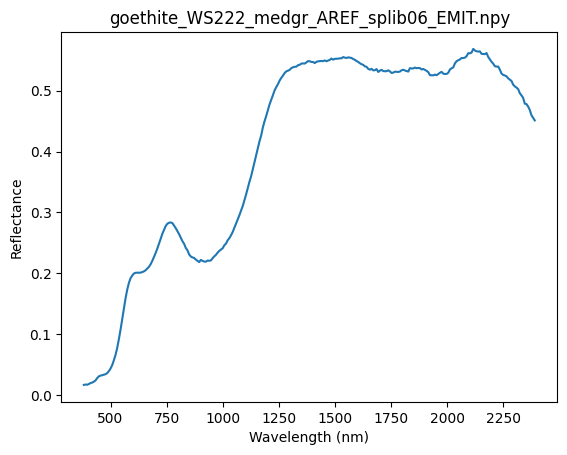

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

emit_nc = "/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L1B/L1B_RAD/EMIT_L1B_RAD_001_20230227T111506_2305807_012.nc"
npy_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/goethite_WS222_medgr_AREF_splib06_EMIT.npy"

# read EMIT wavelength centers (nm)
with Dataset(emit_nc, "r") as ds:
    g = ds.groups["sensor_band_parameters"]
    wl = np.array(g.variables["wavelengths"][:], dtype=float)
    fill = getattr(g.variables["wavelengths"], "_FillValue", -9999.0)
    wl[wl == fill] = np.nan

print (wl.min(), wl.max(), np.isnan(wl).sum())

y = np.load(npy_path).astype(float)
print(np.nanmin(y), np.nanmax(y), np.isnan(y).sum())
idx = np.where(np.isnan(y))[0]
print (wl[idx])

# keep finite points
m = np.isfinite(wl) & np.isfinite(y)

plt.figure()
plt.plot(wl[m], y[m])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title(npy_path.split("/")[-1])
plt.show()


In [5]:
# --- quick sanity check (units + overlap) ---
print(
    f"USGS wl min/max: {np.nanmin(spec_wl_um):.4f} .. {np.nanmax(spec_wl_um):.4f} um "
    f"(n={spec_wl_um.size})"
)

print(
    f"Converted wl min/max: {np.nanmin(spec_wl_nm):.1f} .. {np.nanmax(spec_wl_nm):.1f} nm"
)

emit_min = np.nanmin(emit_centers_nm)
emit_max = np.nanmax(emit_centers_nm)
print(
    f"EMIT centers min/max: {emit_min:.1f} .. {emit_max:.1f} nm "
    f"(bands={np.isfinite(emit_centers_nm).sum()}/{emit_centers_nm.size})"
)

# overlap check
ov_min = max(np.nanmin(spec_wl_nm), emit_min)
ov_max = min(np.nanmax(spec_wl_nm), emit_max)
ok = ov_max > ov_min
print(f"Overlap (spectrum vs EMIT centers): {ov_min:.1f} .. {ov_max:.1f} nm  ->  {'OK' if ok else 'NO OVERLAP'}")

# optional: how many EMIT bands are fully covered by the spectrum range (center within spectrum)
covered = np.isfinite(emit_centers_nm) & (emit_centers_nm >= np.nanmin(spec_wl_nm)) & (emit_centers_nm <= np.nanmax(spec_wl_nm))
print(f"EMIT band centers within spectrum range: {covered.sum()}/{emit_centers_nm.size}")


NameError: name 'spec_wl_um' is not defined

In [6]:
#path to L2B file
nc_file_path = '/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230323T230031_2308215_010.nc'

# Call
ncdump(nc_file_path)

dd=nc.Dataset(nc_file_path)
#dd.get_variables_by_attributes
# to list the groups
print(dd.groups.keys())

mineral2 = dd.groups['mineral_metadata'].variables['name'][2]
print(f" Mineral 4 name: {mineral2}")

mineral193 = dd.groups['mineral_metadata'].variables['name'][193]
print(f" Mineral 193 name: {mineral193}")

#group1=dd.variables['group_1_band_depth'][:]
#print(np.max(group1))

#group2=dd.variables['group_2_band_depth'][:]
#print(np.min(group2))

band1=dd.variables['group_1_band_depth'][:]
print(f"group1band: {band1}")

min1=dd.variables['group_1_mineral_id'][:]
print(f"group1min: {min1}")

min2=dd.variables['group_2_mineral_id'][:]
print(f"group1min: {min2}")



File format: NETCDF4
Dimensions:
	downtrack: size 2208
	crosstrack: size 1242
	bands: size 4
	ortho_y: size 2603
	ortho_x: size 3029
	minerals: size 294
Variables:
	group_1_band_depth: shape (2208, 1242), type float32
		_FillValue: -9999.0
		long_name: Group 1 Band Depth
		units: unitless
	group_1_mineral_id: shape (2208, 1242), type int16
		_FillValue: -9999
		long_name: Group 1 Mineral ID
		units: unitless
	group_2_band_depth: shape (2208, 1242), type float32
		_FillValue: -9999.0
		long_name: Group 2 Band Depth
		units: unitless
	group_2_mineral_id: shape (2208, 1242), type int16
		_FillValue: -9999
		long_name: Group 2 Mineral ID
		units: unitless
Attributes:
	ncei_template_version: NCEI_NetCDF_Swath_Template_v2.0
	summary: The Earth Surface Mineral Dust Source Investigation (EMIT) is an Earth Ventures-Instrument (EVI-4) Mission that maps the surface mineralogy of arid dust source regions via imaging spectroscopy in the visible and short-wave infrared (VSWIR). Installed on the Inte

In [5]:
#path to L1B obs test file
nc_file_path = '/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L1B/L1B_OBS/EMIT_L1B_OBS_001_20230226T120427_2305708_017.nc'

# Call
ncdump(nc_file_path)

dd=nc.Dataset(nc_file_path)
#dd.get_variables_by_attributes
# to list the groups
print(dd.groups.keys())

fit=dd.variables['obs'][:]
#print(fit)

band=dd.groups['sensor_band_parameters'].variables['observation_bands'][:]

print(f"bands: {band}")


File format: NETCDF4
Dimensions:
	downtrack: size 1280
	crosstrack: size 1242
	bands: size 11
	ortho_y: size 2025
	ortho_x: size 1838
Variables:
	obs: shape (1280, 1242, 11), type float32
		_FillValue: -9999.0
		long_name: Observation Data
Attributes:
	ncei_template_version: NCEI_NetCDF_Swath_Template_v2.0
	summary: The Earth Surface Mineral Dust Source Investigation (EMIT) is an Earth Ventures-Instrument (EVI-4) Mission that maps the surface mineralogy of arid dust source regions via imaging spectroscopy in the visible and short-wave infrared (VSWIR). Installed on the International Space Station (ISS), the EMIT instrument is a Dyson imaging spectrometer that uses contiguous spectroscopic measurements from 410 to 2450 nm to resolve absoprtion features of iron oxides, clays, sulfates, carbonates, and other dust-forming minerals. During its one-year mission, EMIT will observe the sunlit Earth's dust source regions that occur within +/-52° latitude and produce maps of the source regions t

In [ ]:
# did not use L2A product
nc_file_path = '/Users/kmccoy/Documents/USC/Research/EMIT/EMIT_L2A_RFL_001_20230220T194126_2305113_011.nc'
dd=nc.Dataset(nc_file_path)
#dd.get_variables_by_attributes
# to list the groups
print(dd.groups.keys())


# Access the 'wavelengths' variable in the 'sensor_band_parameters' group
wavelengths = dd.groups['sensor_band_parameters'].variables['wavelengths'][:]
goodwavelengths = dd.groups['sensor_band_parameters'].variables['good_wavelengths'][:]
print(goodwavelengths)


dict_keys(['sensor_band_parameters', 'location'])
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>Work with EMIT test data: extract TOA reflectance (by wavelength) and group banddepth

In [4]:
#get Q, group banddepth 

# Define folder path
folder = "/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW"
variable_name = "group_2_band_depth"  # Replace with the actual variable name
expected_size = 1589760  # Expected flattened dimension
output_file = "/Volumes/LaCie/Dissertation/data/SouthwestUS/group2_banddepthSW.npy"

# Initialize list to store flattened arrays
flattened_data = []

# Process each NetCDF file in the folder
for file in sorted(os.listdir(folder)):
    if file.endswith(".nc"):
        file_path = os.path.join(folder, file)
        print(file_path)
        
        # Open NetCDF file
        with xr.open_dataset(file_path) as ds:
            if variable_name in ds:
                # Extract variable and flatten it
                flattened_array = ds[variable_name].values.flatten()
                
                # Check if the flattened dimension matches the expected size
                if flattened_array.size == expected_size:
                    flattened_data.append(flattened_array)
                else:
                    print(f"Skipping {file} due to unexpected size: {flattened_array.size}")
            else:
                print(f"Variable '{variable_name}' not found in {file}")

# Convert list to numpy array and ensure correct shape
if flattened_data:
    final_array = np.vstack(flattened_data)
    
    # Save the array to a .npy file
    np.save(output_file, final_array)
    print("Final array shape:", final_array.shape)
else:
    print("No valid data collected.")





/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230323T230031_2308215_010.nc
Skipping EMIT_L2B_MIN_001_20230323T230031_2308215_010.nc due to unexpected size: 2742336
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230014_2308415_001.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230026_2308415_002.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230038_2308415_003.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230050_2308415_004.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230102_2308415_005.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230114_2308415_006.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230125_2308415_007.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MI

In [6]:
#get mineral ID

# Define folder path
folder = "/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW"
variable_name = "group_2_mineral_id"  # Replace with the actual variable name
expected_size = 1589760  # Expected flattened dimension
output_file = "/Volumes/LaCie/Dissertation/data/SouthwestUS/group2_mineralIDSW.npy"

# Initialize list to store flattened arrays
flattened_data = []

# Process each NetCDF file in the folder
for file in sorted(os.listdir(folder)):
    if file.endswith(".nc"):
        file_path = os.path.join(folder, file)
        print(file_path)
        
        # Open NetCDF file
        with xr.open_dataset(file_path) as ds:
            if variable_name in ds:
                # Extract variable and flatten it
                flattened_array = ds[variable_name].values.flatten()
                
                # Check if the flattened dimension matches the expected size
                if flattened_array.size == expected_size:
                    flattened_data.append(flattened_array)
                else:
                    print(f"Skipping {file} due to unexpected size: {flattened_array.size}")
            else:
                print(f"Variable '{variable_name}' not found in {file}")

# Convert list to numpy array and ensure correct shape
if flattened_data:
    final_array = np.vstack(flattened_data)
    
    # Save the array to a .npy file
    np.save(output_file, final_array)
    print("Final array shape:", final_array.shape)
else:
    print("No valid data collected.")





/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230323T230031_2308215_010.nc
Skipping EMIT_L2B_MIN_001_20230323T230031_2308215_010.nc due to unexpected size: 2742336
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230014_2308415_001.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230026_2308415_002.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230038_2308415_003.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230050_2308415_004.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230102_2308415_005.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230114_2308415_006.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MINSW/EMIT_L2B_MIN_001_20230325T230125_2308415_007.nc
/Volumes/LaCie/Dissertation/data/SouthwestUS/EMITL2B_MI

In [ ]:
# extract radiance from .nc file; dont use if want TOA reflectance

folder = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/EMITL1BRAD_test"
variable_name = "radiance"  # Variable to extract
expected_size = 1589760  # Expected flattened dimension

# Get all NetCDF files in the folder
files = [f for f in sorted(os.listdir(folder)) if f.endswith(".nc")]
if not files:
    raise FileNotFoundError("No NetCDF files found in the folder.")

# Open first valid file to determine number of wavelengths (w)
first_file = os.path.join(folder, files[0])
with xr.open_dataset(first_file, engine="netcdf4") as ds:
    num_wavelengths = ds[variable_name].shape[2]  # Get the size of the 3rd dimension

# Iterate over each wavelength index
for w in range(num_wavelengths):
    flattened_data = []
    
    # Process each NetCDF file in the folder
    for file in files:
        file_path = os.path.join(folder, file)
        
        # Open NetCDF file with explicit engine
        try:
            with xr.open_dataset(file_path, engine="netcdf4") as ds:
                if variable_name in ds:
                    # Extract the w-th slice of the 3rd dimension
                    radiance_w = ds[variable_name].isel(bands=w).values
                    flattened_array = radiance_w.flatten()
                    
                    # Check if the flattened dimension matches the expected size
                    if flattened_array.size == expected_size:
                        flattened_data.append(flattened_array)
                    else:
                        print(f"Skipping {file} for w={w} due to unexpected size: {flattened_array.size}")
                else:
                    print(f"Variable '{variable_name}' not found in {file}")
        except OSError as e:
            print(f"Error opening file {file}: {e}")
            continue
    
    # Convert list to numpy array and ensure correct shape
    if flattened_data:
        final_array = np.vstack(flattened_data)
        
        # Save the array to a .npy file
        output_file = f"radiance_test_{w}.npy"
        np.save(output_file, final_array)
        print(f"Final array for w={w} saved to {output_file} with shape: {final_array.shape}")
    else:
        print(f"No valid data collected for w={w}.")


In [ ]:
# run this after run_TOA.py. this will extract TOA refl by wavelength. Probably best to move to .py script in future

folder = "/Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW"
expected_size = 1589760  # Expected flattened dimension
num_wavelengths = 285  # Given fixed number of wavelengths

# Get sorted file names
files = sorted(os.listdir(folder))

# Set to store filenames that failed validation
skipped_files = set()

# Iterate over each wavelength index
for w in range(num_wavelengths):
    valid_data = []

    # Process each .npy file in the folder
    for file in files:
        if file in skipped_files:
            continue  # Skip files that were previously marked as problematic

        file_path = os.path.join(folder, file)

        try:
            radiance = np.load(file_path, mmap_mode='r')  # Memory-mapped loading

            # Extract and flatten the w-th wavelength slice
            radiance_w = radiance[:, :, w].ravel()  

            # Ensure correct size
            if radiance_w.size == expected_size:
                valid_data.append(radiance_w)
            else:
                print(f"Skipping {file} for w={w}: Unexpected size {radiance_w.size}, expected {expected_size}.")
                skipped_files.add(file)  # Store in the skip list
        except Exception as e:
            print(f"Error processing {file}: {e}")
            skipped_files.add(file)  # Store in the skip list

    # Save only if valid data is collected
    if valid_data:
        final_array = np.vstack(valid_data).astype(np.float32)  # Convert to array & ensure dtype consistency
        output_file = os.path.join(folder, f"TOArefl_{w}_test.npy")
        np.save(output_file, final_array)
        print(f"Saved {output_file} with shape {final_array.shape}")
    else:
        print(f"No valid data for w={w}, skipping file save.")




Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_0_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_1_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_2_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_3_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_4_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_5_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_6_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_7_test.npy with shape (52, 1589760)
Saved /Volumes/LaCie/Dissertation/data/SouthwestUS/TOA_reflectance_SW/TOArefl_8_test.npy

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>Utils

In [ ]:
# count number of files in folder

folder = "/Volumes/test/USC/Research/Dissertation/Data/TOA_reflectance_test"
#variable_name = "radiance"  # Variable to extract
#expected_size = 1589760  # Expected flattened dimension

# Get all NetCDF files in the folder
files = [f for f in sorted(os.listdir(folder)) if f.endswith(".npy")]
if not files:
    raise FileNotFoundError("No NetCDF files found in the folder.")

print(len(files))

40


In [ ]:
file_path= "/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/group1_banddepth.npy"
# various statistics: 
def count_values(file_path):
    """
    Counts the number of NaN values, zeros, and negative numbers in a given .npy file.
    
    Parameters:
        file_path (str): Path to the .npy file.
    
    Returns:
        dict: Counts of NaNs, zeros, and negative numbers in the file.
    """
    try:
        data = np.load(file_path)
        nan_count = np.isnan(data[7,:]).sum()
        zero_count = np.sum(data[7,:] == 0)
        negative_count = np.sum(data < 0)
        
        print(f"Number of NaNs in {file_path}: {nan_count}")
        print(f"Number of zeros in {file_path}: {zero_count}")
        print(f"Number of negative numbers in {file_path}: {negative_count}")
        
        return {"NaNs": nan_count, "Zeros": zero_count, "Negatives": negative_count}
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print(count_values(file_path))



Number of NaNs in /Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/group1_banddepth.npy: 1271808
Number of zeros in /Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/group1_banddepth.npy: 1
Number of negative numbers in /Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/group1_banddepth.npy: 0
{'NaNs': np.int64(1271808), 'Zeros': np.int64(1), 'Negatives': np.int64(0)}


In [ ]:
#shape of files

file_path = "/Volumes/big24Tb/USC/Research/Dissertation/Data/TOA_Reflectance_train/TOAref_20220904T014159_2224701_001.npy" 
#count_values(file_path)
k=np.load("/Volumes/big24Tb/USC/Research/Dissertation/Data/TOA_Reflectance_train/TOAref_20220904T014159_2224701_001.npy")
print(k.shape)

(1280, 1242, 285)


In [ ]:
# make sure folders have corresponding files

folder1 = "/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/L2B_Unc"
folder2 = "/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/L2B_Min"

# Function to extract unique identifiers after '001_'
def get_filtered_filenames(folder):
    filenames = set()
    for file in os.listdir(folder):
        if "001_" in file:  # Ensure '001_' is actually present
            filenames.add(file.split("001_", 1)[-1])  # Split only at first occurrence
    return filenames

# Get filenames without '001_' prefix
files1 = get_filtered_filenames(folder1)
files2 = get_filtered_filenames(folder2)

# Find differences
only_in_folder1 = files1 - files2
only_in_folder2 = files2 - files1

# Display results
if only_in_folder1:
    print("Files in", folder1, "but not in", folder2, ":")
    print("\n".join(only_in_folder1))
else:
    print("No unique files in", folder1)

if only_in_folder2:
    print("Files in", folder2, "but not in", folder1, ":")
    print("\n".join(only_in_folder2))
else:
    print("No unique files in", folder2)

Files in /Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/L2B_Unc but not in /Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/L2B_Min :
20230226T120129_2305708_002.nc
20230225T080507_2305605_005.nc
20230226T085007_2305706_002.nc
20230225T080422_2305605_002.nc
20230225T125054_2305608_002.nc
20230227T080447_2305805_002.nc
20230225T081126_2305605_037.nc
20230227T081031_2305805_031.nc
20230227T063608_2305804_029.nc
20230226T054452_2305704_010.nc
20230225T063104_2305604_003.nc
20230226T085204_2305706_005.nc
20230227T111319_2305807_003.nc
20230226T120117_2305708_001.nc
20230227T063244_2305804_014.nc
20230226T054428_2305704_008.nc
20230226T085152_2305706_004.nc
20230226T054416_2305704_007.nc
20230226T054440_2305704_009.nc
20230227T080459_2305805_003.nc
20230225T080434_2305605_003.nc
20230227T093637_2305806_002.nc
20230226T072357_2305705_037.nc
20230227T063433_2305804_021.nc
20230225T080446_2305605_004.nc
20230225T125130_2305608_005.nc
20230227T111307_

In [ ]:
k=np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/radiance_pca_output/radiance_1.npy')
print(k.shape)

(396, 1589760)


In [ ]:


# === Parameters ===
folder_l1b = '/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/radiance_pca_output'
l2b_file = '/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/group1_banddepth.npy'
num_samples = 1000

# === Get sorted list of radiance files, skip *_pca.npy ===
l1b_files = sorted([
    f for f in os.listdir(folder_l1b)
    if f.startswith('radiance_') and f.endswith('.npy') and '_pca' not in f
])

# === Check shape from first L1B file ===
example_file = np.load(os.path.join(folder_l1b, l1b_files[0]))
num_rows, num_cols = example_file.shape
print(f"Example L1B file shape: {num_rows}, {num_cols}")

# === Generate random row and column indices ===
row_idx = random.randint(0, num_rows - 1)
col_indices = random.sample(range(num_cols), num_samples)
print(f"Randomly selected row: {row_idx}")
print(f"Randomly selected columns: {col_indices[:10]}...")

# === Initialize results ===
l1b_nan_counts = []
both_not_nan_counts = []

# === Load L2B data and check shape ===
l2b_data = np.load(l2b_file)
if l2b_data.shape[1] < num_cols:
    raise ValueError(f"L2B file has fewer columns ({l2b_data.shape[1]}) than L1B ({num_cols})!")

l2b_row_data = l2b_data[row_idx, :]
l2b_sample_values = l2b_row_data[col_indices]
l2b_nan = np.isnan(l2b_sample_values)
l2b_nan_count = np.sum(l2b_nan)

# === Process each L1B file ===
for f in l1b_files:
    file_path = os.path.join(folder_l1b, f)
    data = np.load(file_path)
    row_data = data[row_idx, :]
    sample_values = row_data[col_indices]
    l1b_nan = np.isnan(sample_values)
    both_not_nan = (~l1b_nan) & (~l2b_nan)

    l1b_nan_counts.append(np.sum(l1b_nan))
    both_not_nan_counts.append(np.sum(both_not_nan))

# === Print summary ===
print("\nSummary of results:")
for i, f in enumerate(l1b_files):
    print(f"{f}: L1B NaNs = {l1b_nan_counts[i]}, Both not NaN = {both_not_nan_counts[i]}")
print(f"L2B file: L2B NaNs in row = {l2b_nan_count}")


Example L1B file shape: 396, 1589760
Randomly selected row: 78
Randomly selected columns: [1142782, 738687, 1021839, 1324737, 349130, 1459305, 1448101, 170134, 302276, 419792]...

Summary of results:
radiance_0.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_1.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_10.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_100.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_101.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_102.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_103.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_104.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_105.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_106.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_107.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_108.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_109.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_11.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_110.npy: L1B NaNs = 0, Both not NaN = 1000
radiance_111.npy: L1B NaNs

In [ ]:
#Create X to go to Plom. this is .npy for big files; must change to .txt on hpc
# === Load files ===
band_depthPCA = np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/banddepthPCA99.npy')
print("band_depthPCA shape:", band_depthPCA.shape)

radiance_PCA = np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/radiance_pca_output/radiance_concat_pca.npy')
print("radiance_PCA shape:", radiance_PCA.shape)

# === Check matching rows ===
if radiance_PCA.shape[0] != band_depthPCA.shape[0]:
    raise ValueError(f"Row mismatch! radiance_PCA has {radiance_PCA.shape[0]} rows, band_depthPCA has {band_depthPCA.shape[0]} rows")

# === Concatenate horizontally ===
Rad_g1band_g2band = np.hstack([radiance_PCA, band_depthPCA])
print("Final concatenated shape:", Rad_g1band_g2band.shape)

# === Set output directory and file ===
output_dir = '/Users/kmccoy/Documents/USC/Research/Dissertation/Data'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'Rad_g1band_g2band.npy')

# === Save as binary ===
np.save(output_file, Rad_g1band_g2band)
print(f"Saved concatenated binary file to: {output_file}")

In [ ]:
#Create X to go to Plom. this is .npy for smaller files that can be handled with .txt
# === Load files ===
band_depthPCA = np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/L2B/banddepthPCA99.npy')
print("band_depthPCA shape:", band_depthPCA.shape)

radiance_PCA = np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/Africa_MiddleEast/radiance_pca_output/radiance_concat_pca.npy')
print("radiance_PCA shape:", radiance_PCA.shape)

# === Check matching rows ===
if radiance_PCA.shape[0] != band_depthPCA.shape[0]:
    raise ValueError(f"Row mismatch! radiance_PCA has {radiance_PCA.shape[0]} rows, band_depthPCA has {band_depthPCA.shape[0]} rows")

# === Concatenate horizontally ===
Rad_g1band_g2band = np.hstack([radiance_PCA, band_depthPCA])
print("Final concatenated shape:", Rad_g1band_g2band.shape)

# === Set output directory and file ===
output_dir = '/Users/kmccoy/Documents/USC/Research/Dissertation/Data'
os.makedirs(output_dir, exist_ok=True)
output_file_txt = os.path.join(output_dir, 'Rad_g1band_g2band.txt')

# === Save as text file ===
np.savetxt(output_file_txt, Rad_g1band_g2band, fmt='%.6f')
print(f"Saved concatenated text file to: {output_file_txt}")
